## 1. Data Collection

### Source & Method
The ACS 5-Year Estimates are published annually by the U.S. Census Bureau and are freely downloadable from [data.census.gov](https://data.census.gov). The three Data Profile tables (DP03, DP04, DP05) were downloaded at the **county level** for the 2019 survey year — the most recent pre-COVID full-year estimates available at time of collection.

**Why ACS and not an API?**  
The Census Bureau does offer a public API (`api.census.gov`). However, bulk county-level extraction across three full DP tables is substantially simpler via direct CSV download, and the resulting files are identical in content.

**Why 2019?**  
- 2019 is the last pre-COVID year, avoiding pandemic-driven distortions in employment, poverty, and housing metrics
- Temporally aligned with the food access dataset (2015–2019 window)
- ACS 5-year estimates pool 5 years of survey data for stable county-level estimates — appropriate for rural counties with small sample sizes

### Columns Selected
From hundreds of ACS variables, we extract the six most relevant to food access research:

| ACS Variable | Renamed | Rationale |
|---|---|---|
| `DP03_0062E` | `MedianIncome` | Primary economic capacity indicator |
| `DP03_0119PE` | `PovertyRate` | Core food insecurity driver |
| `DP03_0066PE` | `UnemploymentRate` | Structural economic distress marker |
| `DP04_0058PE` | `NoVehicleRate` | Transportation barrier to food access |
| `DP04_0003PE` | `HousingVacancyRate` | Housing instability / community stability |
| `DP05_0018E` | `MedianAge` | Mobility and vulnerability indicator |
| `DP05_0037PE` | `HispanicShare` | Demographic equity variable |

### ⚠️ Data Ethics & Limitations
> - **Survey estimates carry margins of error** — ACS values are estimates, not exact counts. Margin-of-error columns (`*M`, `*PM`) are dropped here but should be considered in any inference.
> - **5-year pooling:** County estimates represent an average over 2015–2019 — they do not reflect a single point in time.
> - **Hispanic/Latino framing:** Using ethnicity as a risk variable requires careful framing — the goal is to identify underserved populations, not to attribute food insecurity to ethnicity itself.
> - **FIPS boundary changes:** Rare county mergers/splits between 2019 and the food access datasets (2010) may cause small merge losses.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

acs_econ = pd.read_csv(
"/content/drive/MyDrive/data mining/ACSDP5Y2019.DP03-Data.csv",
low_memory=False
)

acs_housing = pd.read_csv(
"/content/drive/MyDrive/data mining/ACSDP5Y2019.DP04-Data.csv",
low_memory=False
)

acs_demo = pd.read_csv(
"/content/drive/MyDrive/data mining/ACSDP5Y2019.DP05-Data.csv",
low_memory=False
)

ACS CSV exports include a second header row (index 0) containing verbose column descriptions. This must be removed before any numeric parsing.

In [3]:
acs_econ = acs_econ.drop(index=0)
acs_housing = acs_housing.drop(index=0)
acs_demo = acs_demo.drop(index=0)

In [4]:
acs_econ.reset_index(drop=True, inplace=True)
acs_housing.reset_index(drop=True, inplace=True)
acs_demo.reset_index(drop=True, inplace=True)

The raw table contains **hundreds of columns** — all ACS DP03 variables including estimates, margins of error (`*M`), and percent margins (`*PM`). Column names are census variable codes (e.g., `DP03_0062E`). All values are stored as strings.

In [5]:
acs_econ.head()

,GEO_ID,NAME,DP03_0001E,DP03_0001M,DP03_0002E,DP03_0002M,DP03_0003E,DP03_0003M,DP03_0004E,DP03_0004M,...,DP03_0133PM,DP03_0134PE,DP03_0134PM,DP03_0135PE,DP03_0135PM,DP03_0136PE,DP03_0136PM,DP03_0137PE,DP03_0137PM,Unnamed: 550
0,0500000US01001,"Autauga County, Alabama",43953,259,25908,671,25458,689,24522,738,...,1.6,13.6,1.8,8.7,2.1,13.8,2.2,23.1,3.4,NaN
1,0500000US01003,"Baldwin County, Alabama",172297,329,99495,1720,99317,1737,95091,1811,...,0.8,10.2,1.0,7.4,1.4,8.0,1.0,21.9,2.2,NaN
2,0500000US01005,"Barbour County, Alabama",20636,101,9262,444,9262,444,8413,448,...,2.4,27.6,2.8,16.8,3.1,29.5,2.7,36.3,5.6,NaN
3,0500000US01007,"Bibb County, Alabama",18492,140,9046,567,9046,567,8387,615,...,3.6,17.1,4.4,6.9,3.2,16.1,5.1,31.6,6.8,NaN
4,0500000US01009,"Blount County, Alabama",45907,152,22715,725,22680,724,21917,680,...,1.5,12.4,1.7,10.9,2.8,11.0,1.9,30.2,4.3,NaN


In [6]:
acs_housing.head()

,GEO_ID,NAME,DP04_0001E,DP04_0001M,DP04_0002E,DP04_0002M,DP04_0003E,DP04_0003M,DP04_0004E,DP04_0004M,...,DP04_0139PM,DP04_0140PE,DP04_0140PM,DP04_0141PE,DP04_0141PM,DP04_0142PE,DP04_0142PM,DP04_0143PE,DP04_0143PM,Unnamed: 574
0,0500000US01001,"Autauga County, Alabama",23493,83,21397,325,2096,313,1.4,0.6,...,4.9,11.4,4.9,8.8,3.5,39.9,6.6,(X),(X),NaN
1,0500000US01003,"Baldwin County, Alabama",114164,219,80930,1127,33234,1128,3.3,0.7,...,2.2,12.2,2.1,9.6,2.0,37.4,3.5,(X),(X),NaN
2,0500000US01005,"Barbour County, Alabama",12013,143,9345,313,2668,267,3.8,1.4,...,4.1,9.6,3.3,8.4,3.4,40.9,5.4,(X),(X),NaN
3,0500000US01007,"Bibb County, Alabama",9185,68,6891,333,2294,328,1.5,1.3,...,4.8,11.6,6.3,8.0,5.0,40.5,10.8,(X),(X),NaN
4,0500000US01009,"Blount County, Alabama",24323,67,20847,394,3476,393,0.7,0.4,...,5.8,10.6,4.2,9.9,3.6,34.4,5.6,(X),(X),NaN


In [7]:
acs_demo.head()

,GEO_ID,NAME,DP05_0001E,DP05_0001M,DP05_0002E,DP05_0002M,DP05_0003E,DP05_0003M,DP05_0004E,DP05_0004M,...,DP05_0085PM,DP05_0086PE,DP05_0086PM,DP05_0087PE,DP05_0087PM,DP05_0088PE,DP05_0088PM,DP05_0089PE,DP05_0089PM,Unnamed: 358
0,0500000US01001,"Autauga County, Alabama",55380,*****,26934,166,28446,166,94.7,1.1,...,0.5,(X),(X),41647,(X),47.6,0.2,52.4,0.2,NaN
1,0500000US01003,"Baldwin County, Alabama",212830,*****,103496,233,109334,233,94.7,0.4,...,0.3,(X),(X),162883,(X),47.9,0.2,52.1,0.2,NaN
2,0500000US01005,"Barbour County, Alabama",25361,*****,13421,80,11940,80,112.4,1.4,...,0.5,(X),(X),19728,(X),53.4,0.3,46.6,0.3,NaN
3,0500000US01007,"Bibb County, Alabama",22493,*****,12150,193,10343,193,117.5,4.1,...,0.3,(X),(X),17662,(X),53.6,0.4,46.4,0.4,NaN
4,0500000US01009,"Blount County, Alabama",57681,*****,28495,142,29186,142,97.6,1.0,...,0.2,(X),(X),42722,(X),48.8,0.3,51.2,0.3,NaN


The ACS `GEO_ID` column has the format `0500000US{FIPS}` (e.g., `0500000US01001`).  
We split on `"US"` and take the right-hand portion to extract the 5-digit FIPS code — our join key for merging with Datasets 1 and 2.

In [8]:
for df in [acs_econ, acs_housing, acs_demo]:
    df["CountyFIPS"] = df["GEO_ID"].str[-5:]

In [9]:
acs_econ[["GEO_ID","CountyFIPS"]].head()

,GEO_ID,CountyFIPS
0,0500000US01001,01001
1,0500000US01003,01003
2,0500000US01005,01005
3,0500000US01007,01007
4,0500000US01009,01009


In [10]:
acs_econ["CountyFIPS"] = (
    acs_econ["GEO_ID"]
    .str.split("US")
    .str[1]
)
acs_housing["CountyFIPS"] = (
    acs_housing["GEO_ID"]
    .str.split("US")
    .str[1]
)
acs_demo["CountyFIPS"] = (
    acs_demo["GEO_ID"]
    .str.split("US")
    .str[1]
)

In [11]:
acs_econ.shape


(3220, 552)

In [12]:
acs_housing.shape


(3220, 576)

In [13]:
acs_demo.shape

(3220, 360)

Missing value Analysis

In [14]:
acs_econ.isnull().mean().sort_values(ascending=False).head(10)

,0
Unnamed: 550,1.0
DP03_0043PM,0.0
DP03_0044PM,0.0
DP03_0045PE,0.0
DP03_0045PM,0.0
DP03_0046PE,0.0
DP03_0046PM,0.0
DP03_0047PE,0.0
DP03_0047PM,0.0
DP03_0048PE,0.0


In [15]:
acs_econ = acs_econ.loc[:, ~acs_econ.columns.str.contains("Unnamed")]
acs_housing = acs_housing.loc[:, ~acs_housing.columns.str.contains("Unnamed")]
acs_demo = acs_demo.loc[:, ~acs_demo.columns.str.contains("Unnamed")]

In [16]:
acs_econ = acs_econ.loc[:, ~acs_econ.columns.str.contains("Unnamed")]
acs_housing = acs_housing.loc[:, ~acs_housing.columns.str.contains("Unnamed")]
acs_demo = acs_demo.loc[:, ~acs_demo.columns.str.contains("Unnamed")]

In [17]:
acs_econ.isnull().mean().sort_values(ascending=False).head(10)

,0
CountyFIPS,0.0
GEO_ID,0.0
NAME,0.0
DP03_0001E,0.0
DP03_0001M,0.0
DP03_0002E,0.0
DP03_0002M,0.0
DP03_0130PE,0.0
DP03_0129PM,0.0
DP03_0129PE,0.0


In [18]:
acs_econ = acs_econ.loc[:, ~acs_econ.columns.str.contains("Unnamed")]
acs_housing = acs_housing.loc[:, ~acs_housing.columns.str.contains("Unnamed")]
acs_demo = acs_demo.loc[:, ~acs_demo.columns.str.contains("Unnamed")]

ACS tables include two types of uncertainty columns:
- `*M` columns — raw margin of error (e.g., `DP03_0062EM`)
- `*PM` columns — percent margin of error (e.g., `DP03_0062EPM`)

These are not analytical variables — they quantify estimation uncertainty. Dropping them reduces each table from hundreds to dozens of usable columns.

In [19]:
acs_econ = acs_econ.loc[:, ~acs_econ.columns.str.endswith(("M","PM"))]
acs_housing = acs_housing.loc[:, ~acs_housing.columns.str.endswith(("M","PM"))]
acs_demo = acs_demo.loc[:, ~acs_demo.columns.str.endswith(("M","PM"))]

Drop All NA columns

In [20]:
acs_econ = acs_econ.dropna(axis=1, how="all")
acs_housing = acs_housing.dropna(axis=1, how="all")
acs_demo = acs_demo.dropna(axis=1, how="all")

In [21]:
acs_econ.isnull().mean().sort_values(ascending=False).head(10)

,0
CountyFIPS,0.0
GEO_ID,0.0
NAME,0.0
DP03_0001E,0.0
DP03_0002E,0.0
DP03_0122PE,0.0
DP03_0121PE,0.0
DP03_0120PE,0.0
DP03_0119PE,0.0
DP03_0118PE,0.0


In [22]:
for df in [acs_econ, acs_housing, acs_demo]:

    numeric_cols = df.select_dtypes(include="number").columns

    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [23]:
acs_econ.isnull().sum().sum()
acs_housing.isnull().sum().sum()
acs_demo.isnull().sum().sum()

np.int64(0)

In [24]:
for df in [acs_econ, acs_housing, acs_demo]:

    for col in df.columns:

        if col not in ["GEO_ID", "NAME", "CountyFIPS"]:

            df[col] = pd.to_numeric(df[col], errors="coerce")

Data types verification

In [25]:
acs_econ.dtypes.head()

,0
GEO_ID,object
NAME,object
DP03_0001E,int64
DP03_0002E,int64
DP03_0003E,int64


In [26]:
acs_econ.shape

(3220, 277)

After numeric conversion, suppressed small-area estimates create residual missingness. We drop any column that is still more than 30% null — these variables are not reliable enough for county-level analysis.

In [27]:
def drop_high_missing(df, threshold=0.3):

    missing_ratio = df.isnull().mean()

    keep_cols = missing_ratio[missing_ratio < threshold].index

    return df[keep_cols]

acs_econ = drop_high_missing(acs_econ)
acs_housing = drop_high_missing(acs_housing)
acs_demo = drop_high_missing(acs_demo)

In [28]:
print(acs_econ.shape)
print(acs_housing.shape)
print(acs_demo.shape)

(3220, 241)
(3220, 276)
(3220, 176)


Remove Duplicates

In [29]:
acs_econ = acs_econ.drop_duplicates(subset="CountyFIPS")
acs_housing = acs_housing.drop_duplicates(subset="CountyFIPS")
acs_demo = acs_demo.drop_duplicates(subset="CountyFIPS")

In [30]:
acs_econ["CountyFIPS"].nunique()

3220

In [31]:
for df in [acs_econ, acs_housing, acs_demo]:

    numeric_cols = df.select_dtypes(include="number").columns

    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [32]:
acs_econ.isnull().sum().sum()

np.int64(0)

### VARIABLE SELECTION

From the cleaned economic table, we extract three variables directly relevant to food access risk:
- **MedianIncome** (`DP03_0062E`): Purchasing power proxy
- **PovertyRate** (`DP03_0119PE`): % below federal poverty line
- **UnemploymentRate** (`DP03_0066PE`): Labor market distress

In [33]:
econ_vars = acs_econ[[
"CountyFIPS",
"DP03_0062E",   # Median household income
"DP03_0119PE",  # Poverty rate
"DP03_0066PE"   # Unemployment rate
]].copy()

econ_vars.columns = [
"CountyFIPS",
"MedianIncome",
"PovertyRate",
"UnemploymentRate"
]

From the housing table:
- **NoVehicleRate** (`DP04_0058PE`): % households without a vehicle — a critical food access barrier
- **HousingVacancyRate** (`DP04_0003PE`): % housing units vacant — proxy for community disinvestment

In [34]:
housing_vars = acs_housing[[
"CountyFIPS",
"DP04_0058PE",  # No vehicle households
"DP04_0003PE"   # Housing vacancy
]].copy()

housing_vars.columns = [
"CountyFIPS",
"NoVehicleRate",
"HousingVacancyRate"
]

From the demographics table:
- **MedianAge** (`DP05_0018E`): Older populations may have reduced mobility and fixed incomes
- **HispanicShare** (`DP05_0037PE`): Included as an equity variable — Hispanic communities are disproportionately affected by food insecurity in many regions

In [35]:
demo_vars = acs_demo[[
"CountyFIPS",
"DP05_0018E",   # Median age
"DP05_0037PE"   # Hispanic population share
]].copy()

demo_vars.columns = [
"CountyFIPS",
"MedianAge",
"HispanicShare"
]

In [36]:
for df in [acs_econ, acs_housing, acs_demo]:

    numeric_cols = df.columns.drop(["CountyFIPS","NAME"])

    df[numeric_cols] = df[numeric_cols].apply(
        pd.to_numeric,
        errors="coerce"
    )

merge

In [37]:
acs_clean = econ_vars.merge(
housing_vars,
on="CountyFIPS",
how="inner"
).merge(
demo_vars,
on="CountyFIPS",
how="inner"
)

In [38]:
acs_clean["CountyName"] = acs_econ["NAME"].str.split(",").str[0]
acs_clean["State"] = acs_econ["NAME"].str.split(",").str[1]

In [39]:
acs_clean.shape
acs_clean.head()

,CountyFIPS,MedianIncome,PovertyRate,UnemploymentRate,NoVehicleRate,HousingVacancyRate,MedianAge,HispanicShare,CountyName,State
0,01001,58731,12.3,34.7,4.4,8.9,38.2,76.8,Autauga County,Alabama
1,01003,58320,6.9,39.8,3.3,29.1,43.0,86.2,Baldwin County,Alabama
2,01005,32525,23.7,45.2,10.2,22.2,40.4,46.8,Barbour County,Alabama
3,01007,47542,15.0,42.9,6.2,25.0,40.9,76.8,Bibb County,Alabama
4,01009,49358,9.6,38.5,4.1,14.3,40.7,95.5,Blount County,Alabama


In [40]:
acs_clean.isnull().sum()

,0
CountyFIPS,0
MedianIncome,0
PovertyRate,0
UnemploymentRate,0
NoVehicleRate,0
HousingVacancyRate,0
MedianAge,0
HispanicShare,0
CountyName,0
State,0


Post merge sanity check

In [41]:
for col in acs_clean.columns:

    if acs_clean[col].isnull().sum() > 0:

        acs_clean[col].fillna(
            acs_clean[col].median(),
            inplace=True
        )

In [42]:
acs_clean.describe()

,MedianIncome,PovertyRate,UnemploymentRate,NoVehicleRate,HousingVacancyRate,MedianAge,HispanicShare
count,3220.000000,3220.000000,3220.000000,3220.000000,3220.000000,3220.000000,3220.000000
mean,52648.046584,11.602609,37.564472,6.508665,19.128230,41.435466,82.463354
std,14989.826552,7.504720,7.577162,4.677455,11.263071,5.361130,17.213013
min,12441.000000,0.000000,10.300000,0.000000,3.000000,22.300000,3.600000
25%,43524.000000,7.100000,32.900000,4.200000,11.200000,38.300000,75.500000
50%,51485.500000,10.000000,37.500000,5.700000,16.700000,41.300000,89.150000
75%,59519.250000,13.800000,42.200000,7.700000,24.200000,44.500000,94.800000
max,142299.000000,59.900000,78.200000,88.000000,87.200000,67.400000,100.000000


In [43]:
acs_clean["CountyFIPS"].nunique()

3220

In [44]:
from scipy.stats import zscore

risk_vars = [
"PovertyRate",
"UnemploymentRate",
"NoVehicleRate",
"HousingVacancyRate",
"MedianAge",
"HispanicShare"
]

acs_clean[risk_vars] = acs_clean[risk_vars].apply(
    lambda x: zscore(x, nan_policy="omit")
)

Skewness and Kurtosis

In [78]:
import pandas as pd

stat_cols = ["MedianIncome", "PovertyRate", "UnemploymentRate",
             "NoVehicleRate", "HousingVacancyRate", "MedianAge", "HispanicShare"]

skew_kurt = pd.DataFrame({
    "Skewness": acs_clean[stat_cols].skew(),
    "Kurtosis": acs_clean[stat_cols].kurtosis()
}).round(3)

print("Distributional Shape of ACS Variables:")
print(skew_kurt)
print()
print("Interpretation:")
print("  MedianIncome: Slight right skew — a few very high-income counties pull the tail.")
print("  PovertyRate / UnemploymentRate: Right-skewed — most counties are moderate, few are extreme.")
print("  NoVehicleRate: Right-skewed — most counties have low carless rates; urban cores are outliers.")



Distributional Shape of ACS Variables:
                    Skewness  Kurtosis
MedianIncome           0.944     2.894
PovertyRate            2.551     9.360
UnemploymentRate       0.139     0.584
NoVehicleRate          6.499    76.784
HousingVacancyRate     1.527     3.451
MedianAge              0.119     0.812
HispanicShare         -1.660     2.617

Interpretation:
  MedianIncome: Slight right skew — a few very high-income counties pull the tail.
  PovertyRate / UnemploymentRate: Right-skewed — most counties are moderate, few are extreme.
  NoVehicleRate: Right-skewed — most counties have low carless rates; urban cores are outliers.


Correlation Matrix

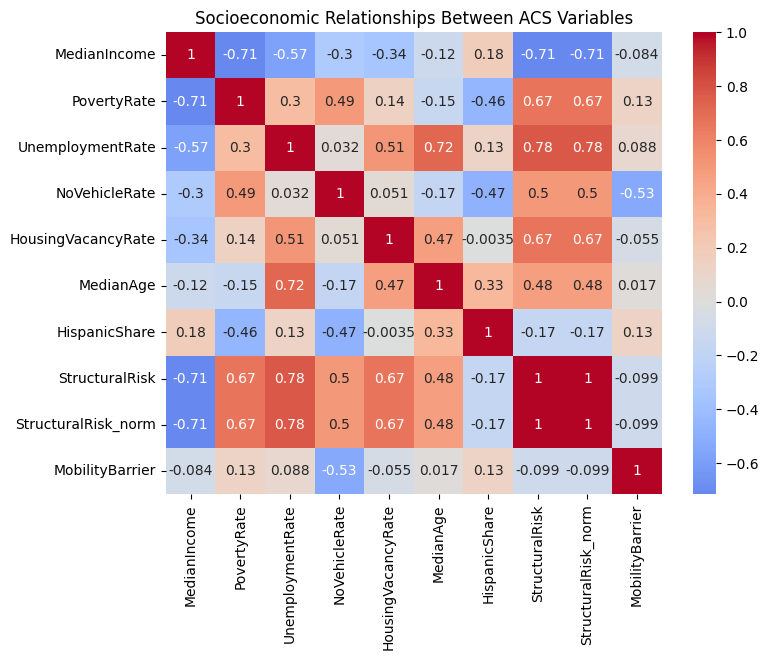

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = acs_clean.select_dtypes(include=["number"])

corr = numeric_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Socioeconomic Relationships Between ACS Variables")

plt.show()

QQ PLot- Normality analysis

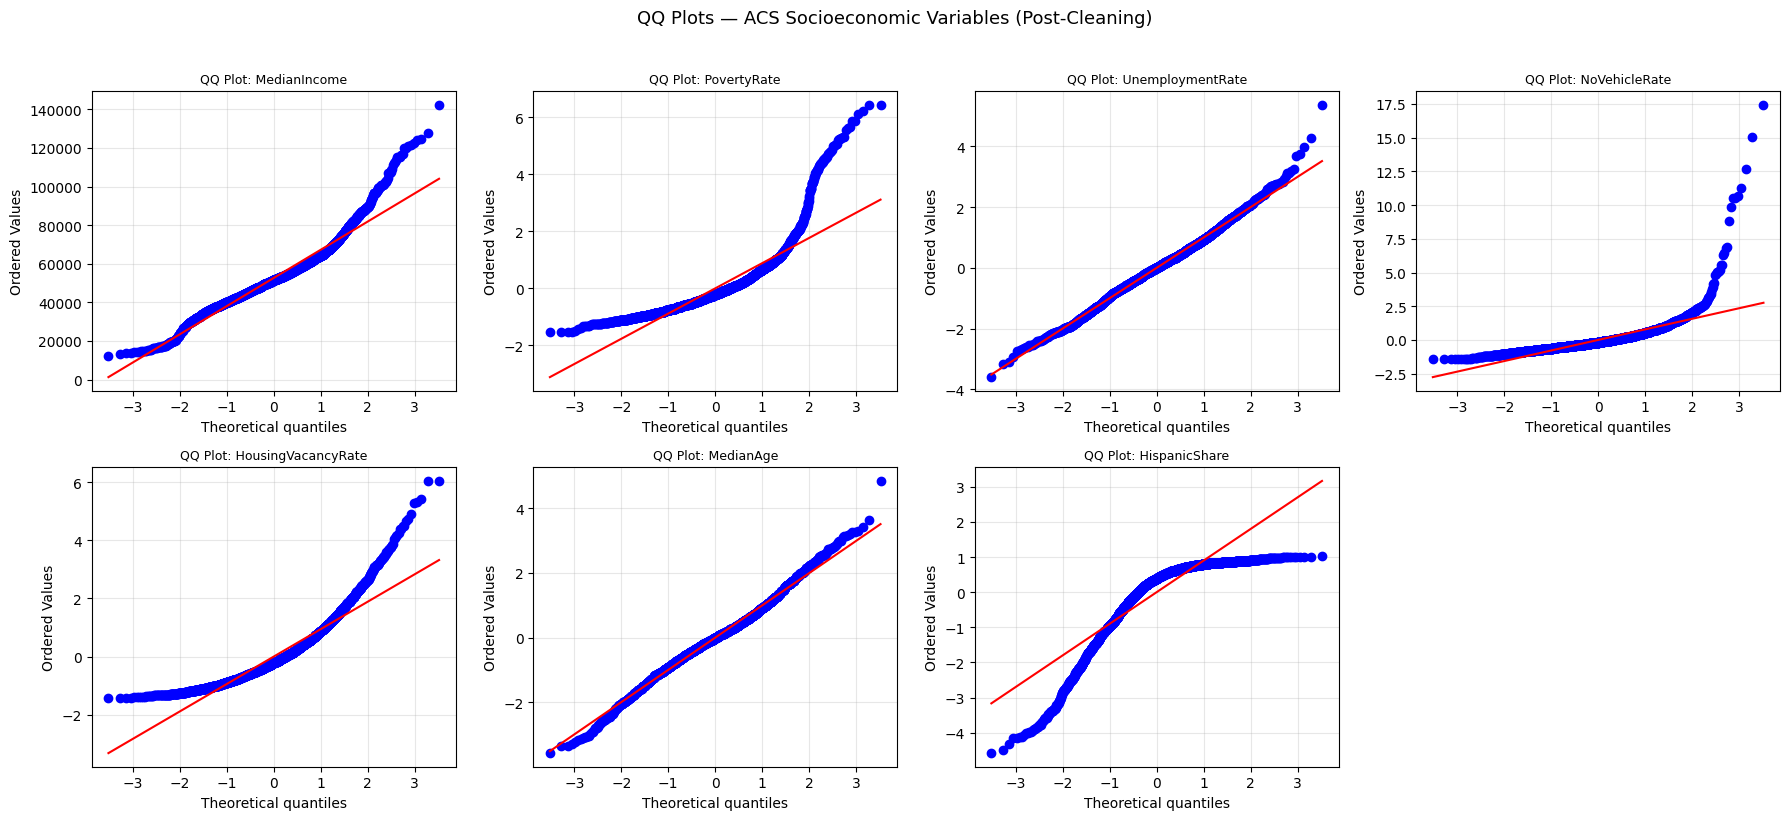

In [81]:
import scipy.stats as stats
qq_cols = ["MedianIncome", "PovertyRate", "UnemploymentRate",
           "NoVehicleRate", "HousingVacancyRate", "MedianAge", "HispanicShare"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(qq_cols):
    data = acs_clean[col].dropna()
    stats.probplot(data, dist="norm", plot=axes[i])
    axes[i].set_title(f"QQ Plot: {col}", fontsize=9)
    axes[i].grid(True, alpha=0.3)

axes[-1].axis("off")
plt.suptitle("QQ Plots — ACS Socioeconomic Variables (Post-Cleaning)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

##raw data viz

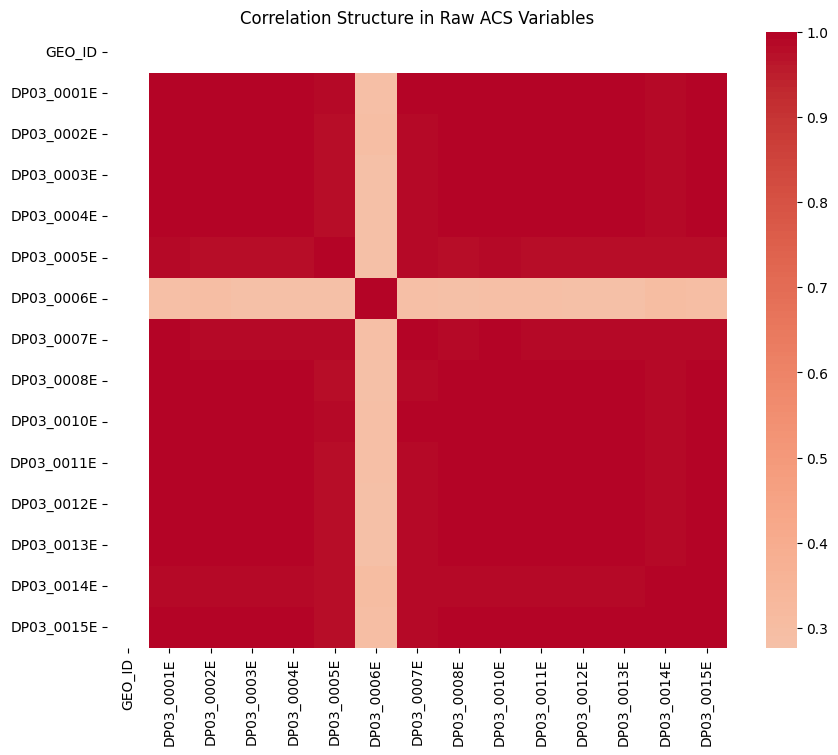

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt


sample_cols = acs_econ.select_dtypes(include="number").columns[:15]

plt.figure(figsize=(10,8))

sns.heatmap(
acs_econ[sample_cols].corr(),
cmap="coolwarm",
center=0
)

plt.title("Correlation Structure in Raw ACS Variables")
plt.show()

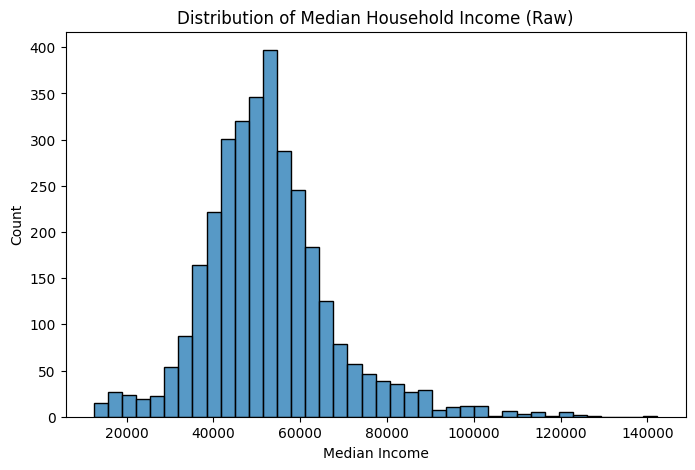

In [46]:
plt.figure(figsize=(8,5))

sns.histplot(
acs_econ["DP03_0062E"],
bins=40
)

plt.title("Distribution of Median Household Income (Raw)")
plt.xlabel("Median Income")
plt.show()

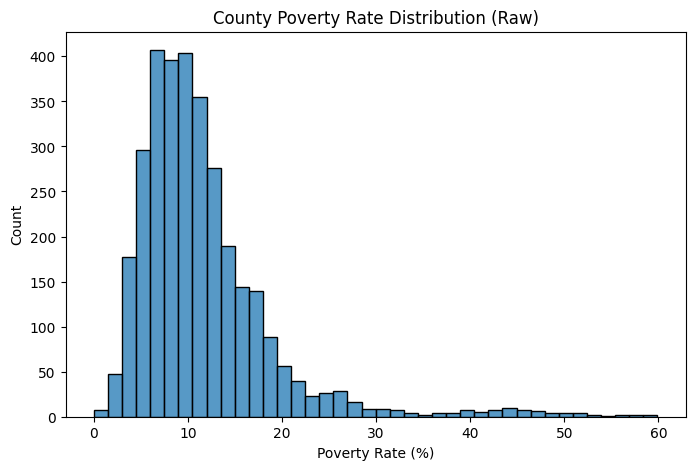

In [47]:
plt.figure(figsize=(8,5))

sns.histplot(
acs_econ["DP03_0119PE"],
bins=40
)

plt.title("County Poverty Rate Distribution (Raw)")
plt.xlabel("Poverty Rate (%)")
plt.show()

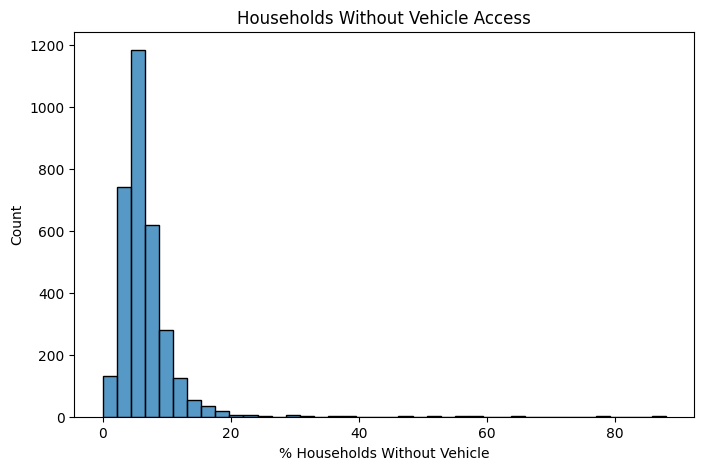

In [48]:
plt.figure(figsize=(8,5))

sns.histplot(
acs_housing["DP04_0058PE"],
bins=40
)

plt.title("Households Without Vehicle Access")
plt.xlabel("% Households Without Vehicle")
plt.show()

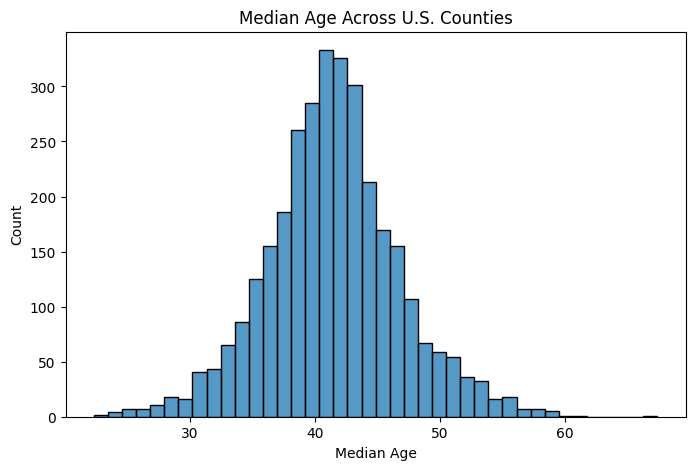

In [49]:
plt.figure(figsize=(8,5))

sns.histplot(
acs_demo["DP05_0018E"],
bins=40
)

plt.title("Median Age Across U.S. Counties")
plt.xlabel("Median Age")
plt.show()

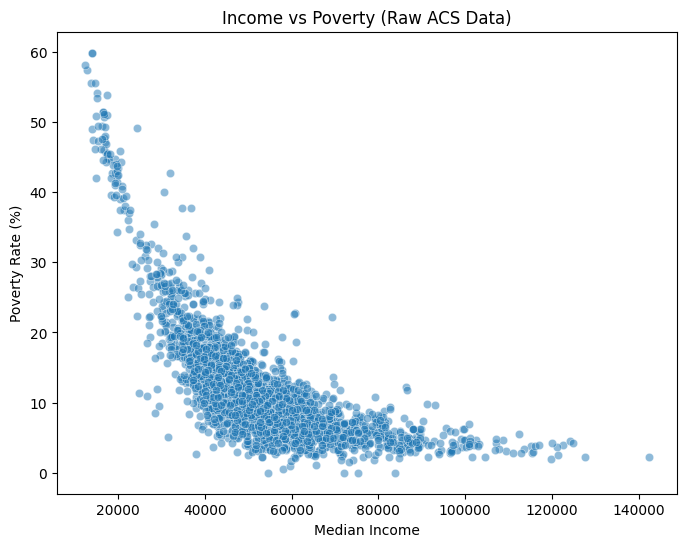

In [50]:
plt.figure(figsize=(8,6))

sns.scatterplot(
x=acs_econ["DP03_0062E"],
y=acs_econ["DP03_0119PE"],
alpha=0.5
)

plt.title("Income vs Poverty (Raw ACS Data)")
plt.xlabel("Median Income")
plt.ylabel("Poverty Rate (%)")
plt.show()

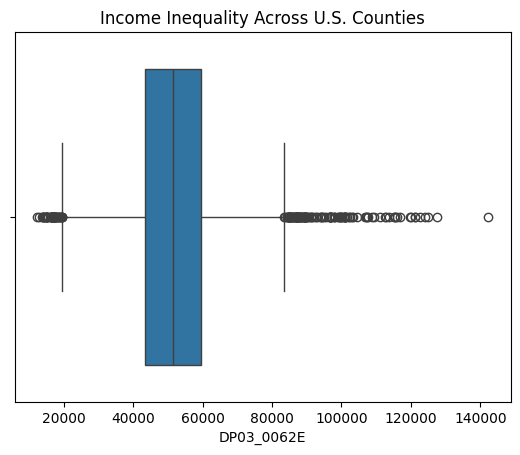

In [51]:
sns.boxplot(x=acs_econ["DP03_0062E"])
plt.title("Income Inequality Across U.S. Counties")
plt.show()

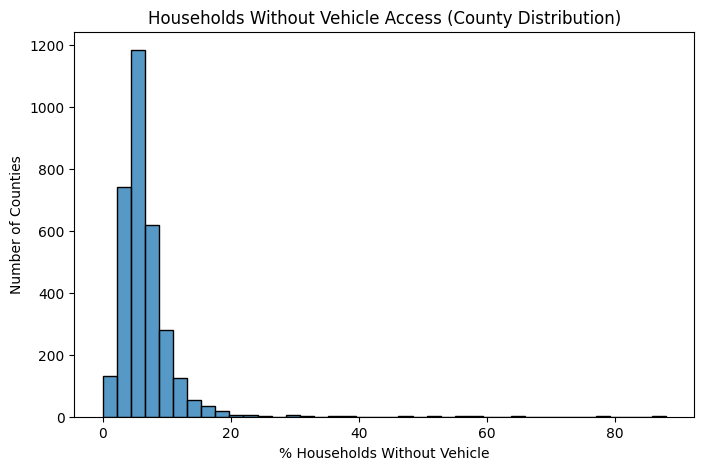

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
acs_housing["DP04_0058PE"],
bins=40
)

plt.title("Households Without Vehicle Access (County Distribution)")
plt.xlabel("% Households Without Vehicle")
plt.ylabel("Number of Counties")

plt.show()

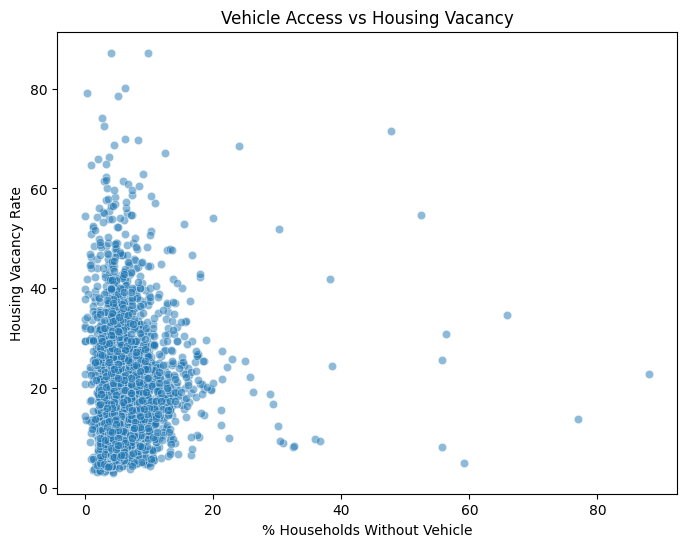

In [53]:
plt.figure(figsize=(8,6))

sns.scatterplot(
x=acs_housing["DP04_0058PE"],
y=acs_housing["DP04_0003PE"],
alpha=0.5
)

plt.title("Vehicle Access vs Housing Vacancy")
plt.xlabel("% Households Without Vehicle")
plt.ylabel("Housing Vacancy Rate")

plt.show()

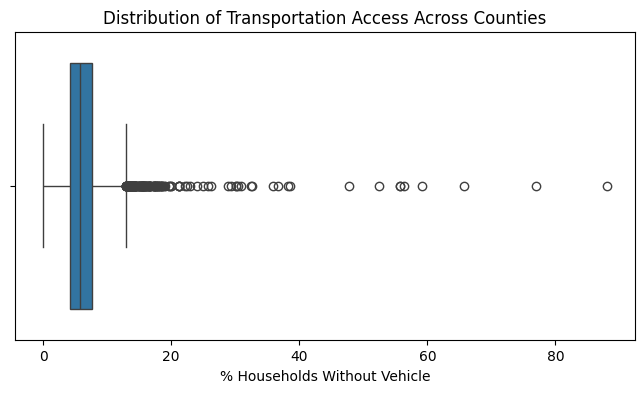

In [54]:
plt.figure(figsize=(8,4))

sns.boxplot(x=acs_housing["DP04_0058PE"])

plt.title("Distribution of Transportation Access Across Counties")
plt.xlabel("% Households Without Vehicle")

plt.show()

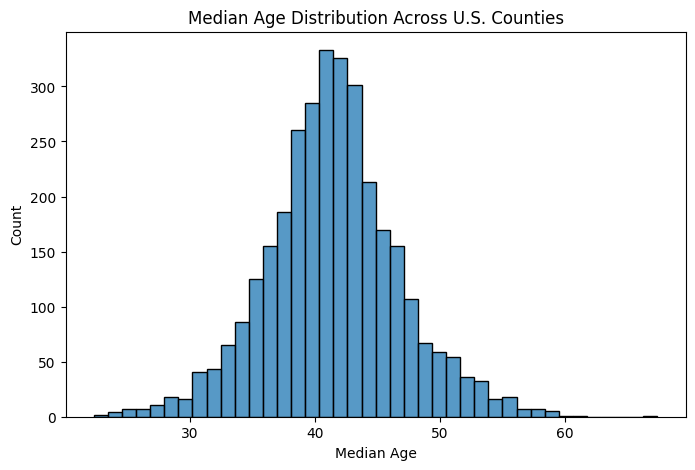

In [55]:
plt.figure(figsize=(8,5))

sns.histplot(
acs_demo["DP05_0018E"],
bins=40
)

plt.title("Median Age Distribution Across U.S. Counties")
plt.xlabel("Median Age")

plt.show()

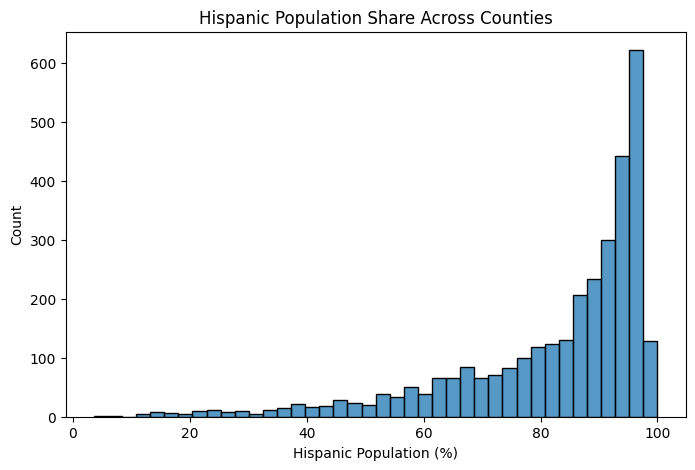

In [56]:
plt.figure(figsize=(8,5))

sns.histplot(
acs_demo["DP05_0037PE"],
bins=40
)

plt.title("Hispanic Population Share Across Counties")
plt.xlabel("Hispanic Population (%)")

plt.show()

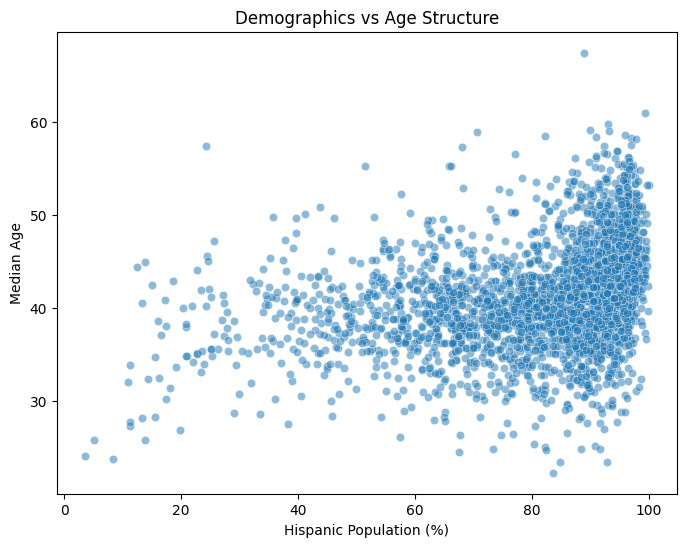

In [57]:
plt.figure(figsize=(8,6))

sns.scatterplot(
x=acs_demo["DP05_0037PE"],
y=acs_demo["DP05_0018E"],
alpha=0.5
)

plt.title("Demographics vs Age Structure")
plt.xlabel("Hispanic Population (%)")
plt.ylabel("Median Age")

plt.show()

##Cleaned Dataset viz

In [58]:
import plotly.express as px

fig = px.histogram(
    acs_clean,
    x="MedianIncome",
    nbins=50,
    title="Income Inequality Across U.S. Counties",
    labels={"MedianIncome": "Median Household Income"},
)

fig.update_layout(
    annotations=[
        dict(
            text="Income disparities across counties may shape food accessibility and purchasing power.",
            showarrow=False,
            y=1.05,
            x=0.5,
            xref="paper",
            yref="paper",
        )
    ]
)

fig.show()

In [59]:
fig = px.scatter(
    acs_clean,
    x="UnemploymentRate",
    y="PovertyRate",
    trendline="ols",
    opacity=0.6,
    title="Structural Relationship Between Unemployment and Poverty",
)

fig.update_layout(
    annotations=[
        dict(
            text="Higher unemployment strongly correlates with higher poverty across counties.",
            showarrow=False,
            x=0.5,
            y=1.05,
            xref="paper",
            yref="paper"
        )
    ]
)

fig.show()

In [60]:
fig = px.histogram(
    acs_clean,
    x="NoVehicleRate",
    nbins=40,
    title="Transportation Barriers Across U.S. Counties",
    labels={"NoVehicleRate": "% Households Without Vehicle"},
)

fig.update_layout(
    annotations=[
        dict(
            text="Transportation barriers may prevent residents from reaching grocery infrastructure.",
            showarrow=False,
            x=0.5,
            y=1.05,
            xref="paper",
            yref="paper"
        )
    ]
)

fig.show()

In [61]:
fig = px.scatter(
    acs_clean,
    x="NoVehicleRate",
    y="PovertyRate",
    opacity=0.6,
    trendline="ols",
    title="Transportation Inequality and Poverty",
)

fig.update_layout(
    annotations=[
        dict(
            text="Transportation barriers and poverty often reinforce each other.",
            showarrow=False,
            x=0.5,
            y=1.05,
            xref="paper",
            yref="paper"
        )
    ]
)

fig.show()

In [62]:
fig = px.histogram(
    acs_clean,
    x="MedianAge",
    nbins=40,
    title="Age Structure Across U.S. Counties",
)

fig.update_layout(
    annotations=[
        dict(
            text="Older populations may face mobility and access challenges.",
            showarrow=False,
            x=0.5,
            y=1.05,
            xref="paper",
            yref="paper"
        )
    ]
)

fig.show()

In [63]:
fig = px.scatter(
    acs_clean,
    x="MedianIncome",
    y="NoVehicleRate",
    opacity=0.6,
    trendline="ols",
    title="Income vs Transportation Access",
)

fig.update_layout(
    annotations=[
        dict(
            text="Lower-income counties tend to have higher transportation barriers.",
            showarrow=False,
            x=0.5,
            y=1.05,
            xref="paper",
            yref="paper"
        )
    ]
)

fig.show()

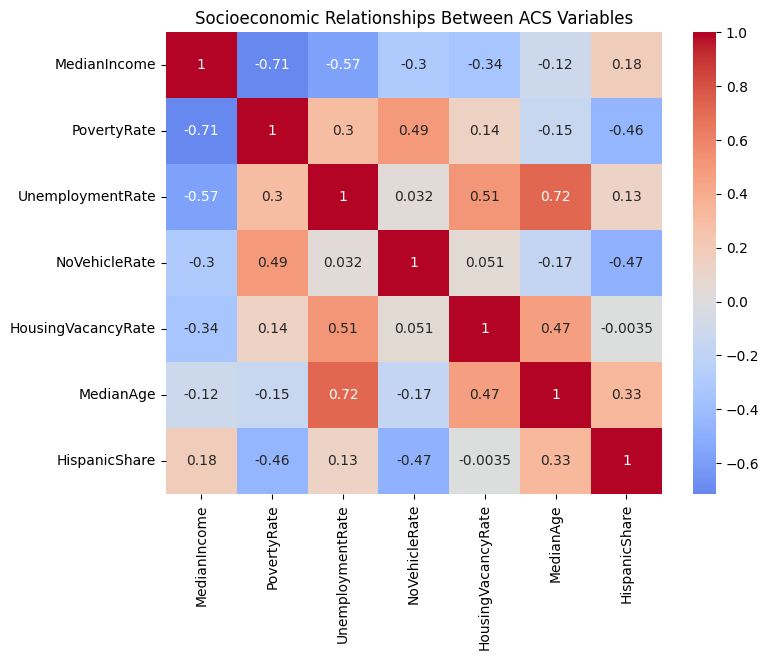

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = acs_clean.select_dtypes(include=["number"])

corr = numeric_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Socioeconomic Relationships Between ACS Variables")

plt.show()

In [65]:
from scipy.stats import zscore

risk_vars = [
"PovertyRate",
"UnemploymentRate",
"NoVehicleRate",
"HousingVacancyRate",
"MedianAge",
"HispanicShare"
]

acs_clean[risk_vars] = acs_clean[risk_vars].apply(
    lambda x: zscore(x, nan_policy="omit")
)
acs_clean["StructuralRisk"] = (
    0.25 * acs_clean["PovertyRate"] +
    0.20 * acs_clean["UnemploymentRate"] +
    0.20 * acs_clean["NoVehicleRate"] +
    0.20 * acs_clean["HousingVacancyRate"] +
    0.10 * acs_clean["MedianAge"] +
    0.05 * acs_clean["HispanicShare"]
)
acs_clean["StructuralRisk_norm"] = zscore(
    acs_clean["StructuralRisk"],
    nan_policy="omit"
)
acs_clean["HighRisk"] = acs_clean["StructuralRisk_norm"] > 1
acs_clean["MobilityBarrier"] = (
    acs_clean["NoVehicleRate"] *
    acs_clean["UnemploymentRate"]
)

In [66]:
acs_clean.head()

,CountyFIPS,MedianIncome,PovertyRate,UnemploymentRate,NoVehicleRate,HousingVacancyRate,MedianAge,HispanicShare,CountyName,State,StructuralRisk,StructuralRisk_norm,HighRisk,MobilityBarrier
0,01001,58731,0.092941,-0.378099,-0.450885,-0.908262,-0.603598,-0.329067,Autauga County,Alabama,-0.401027,-0.672942,False,0.170479
1,01003,58320,-0.626717,0.295081,-0.686092,0.885488,0.291875,0.217116,Baldwin County,Alabama,-0.017741,-0.029770,False,-0.202452
2,01005,32525,1.612221,1.007859,0.789299,0.272772,-0.193173,-2.072205,Barbour County,Alabama,0.694114,1.164755,True,0.795502
3,01007,47542,0.452771,0.704268,-0.066000,0.521410,-0.099895,-0.329067,Bibb County,Alabama,0.318686,0.534769,False,-0.046482
4,01009,49358,-0.266888,0.123486,-0.515032,-0.428744,-0.137206,0.757489,Blount County,Alabama,-0.206626,-0.346729,False,-0.063599


In [67]:
top_risk = acs_clean.nlargest(15, "StructuralRisk")

fig = px.bar(
    top_risk,
    x="StructuralRisk",
    y="CountyFIPS",
    orientation="h",
    title="Counties With Highest Structural Food Access Risk",
)

fig.show()

In [68]:
acs_clean.describe()

,MedianIncome,PovertyRate,UnemploymentRate,NoVehicleRate,HousingVacancyRate,MedianAge,HispanicShare,StructuralRisk,StructuralRisk_norm,MobilityBarrier
count,3220.000000,3.220000e+03,3.220000e+03,3.220000e+03,3.220000e+03,3.220000e+03,3.220000e+03,3.220000e+03,3.220000e+03,3220.000000
mean,52648.046584,-8.826618e-18,-6.619963e-18,1.323993e-17,-1.323993e-17,-2.206654e-17,4.413309e-18,-1.765324e-17,1.323993e-17,0.031780
std,14989.826552,1.000155e+00,1.000155e+00,1.000155e+00,1.000155e+00,1.000155e+00,1.000155e+00,5.960235e-01,1.000155e+00,1.500319
min,12441.000000,-1.546282e+00,-3.598802e+00,-1.391713e+00,-1.432179e+00,-3.569852e+00,-4.582324e+00,-1.466658e+00,-2.461121e+00,-29.358440
25%,43524.000000,-6.000634e-01,-6.156918e-01,-4.936495e-01,-7.040230e-01,-5.849425e-01,-4.046029e-01,-4.012280e-01,-6.732794e-01,-0.128439
50%,51485.500000,-2.135799e-01,-8.510054e-03,-1.729124e-01,-2.156256e-01,-2.527208e-02,3.885249e-01,-5.665241e-02,-9.506541e-02,0.025923
75%,59519.250000,2.928467e-01,6.118713e-01,2.547369e-01,4.503708e-01,5.717098e-01,7.168160e-01,3.126641e-01,5.246650e-01,0.290428
max,142299.000000,6.436602e+00,5.363728e+00,1.742486e+01,6.044740e+00,4.843861e+00,1.018960e+00,3.531746e+00,5.926435e+00,6.716433


In [69]:
acs_clean[["PovertyRate","UnemploymentRate","NoVehicleRate","StructuralRisk"]].head()

,PovertyRate,UnemploymentRate,NoVehicleRate,StructuralRisk
0,0.092941,-0.378099,-0.450885,-0.401027
1,-0.626717,0.295081,-0.686092,-0.017741
2,1.612221,1.007859,0.789299,0.694114
3,0.452771,0.704268,-0.066000,0.318686
4,-0.266888,0.123486,-0.515032,-0.206626


In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

acs_clean["StructuralRisk_norm"] = scaler.fit_transform(
    acs_clean[["StructuralRisk"]]
)

In [71]:
acs_clean["StructuralRisk_norm"].describe()

,StructuralRisk_norm
count,3.220000e+03
mean,1.323993e-17
std,1.000155e+00
min,-2.461121e+00
25%,-6.732794e-01
50%,-9.506541e-02
75%,5.246650e-01
max,5.926435e+00


In [72]:
import plotly.express as px

fig = px.choropleth(
    acs_clean,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations="CountyFIPS",
    color="StructuralRisk_norm",
    color_continuous_scale="Reds",
    scope="usa",
    labels={"StructuralRisk_norm": "Structural Risk Index"},
    title="Geographic Distribution of Structural Food Access Risk"
)

fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})

fig.show()

In [73]:
fig = px.choropleth(
    acs_clean,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations="CountyFIPS",
    color="StructuralRisk_norm",
    scope="usa",
    color_continuous_scale="Reds",
    hover_data=[
        "CountyName",
        "State",
        "PovertyRate",
        "UnemploymentRate",
        "StructuralRisk_norm"
    ]
)

fig.update_layout(
    title="Structural Food System Risk Across U.S. Counties"
)

fig.show()

In [74]:
acs_clean["CountyName"] = acs_econ["NAME"].str.split(",").str[0]
acs_clean["State"] = acs_econ["NAME"].str.split(",").str[1]

In [75]:
fig = px.scatter(
    acs_clean,
    x="PovertyRate",
    y="MobilityBarrier",
    color="StructuralRisk_norm",
    hover_data=["CountyName"],
    title="Economic and Mobility Barriers to Food Access"
)

fig.show()

In [76]:
acs_clean.to_csv(
"/content/drive/MyDrive/data mining/cleaned/acs_clean.csv",
index=False
)